In [5]:
# importing relevant libaries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import os
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
seed = 123 # to ensure we always get the same results
np.random.seed(seed) # to ensure we always get the same results
tf.keras.utils.set_random_seed(seed) # to ensure we always get the same results

In [7]:
# locating to my dataset
data_dir = os.path.expanduser('~/Desktop/ClarityScanDataSet')

In [8]:
# splitting fr training
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,    
    subset="training",
    seed=123,
    image_size=(32, 32),   
    batch_size=32
)
 
# splitting for validation
val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(32, 32),
    batch_size=16,
    shuffle=False
)

Found 233 files belonging to 6 classes.
Using 187 files for training.
Found 233 files belonging to 6 classes.
Using 46 files for validation.


2026-04-24 12:58:04.954679: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-24 12:58:04.954784: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-24 12:58:04.954797: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-24 12:58:04.954838: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 12:58:04.954856: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
# perfoming data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="augmentation_layer")

In [10]:
# This is a CNN Neural Network refernce applied ai tutorial 9
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)), # Convolutional layer from my dimension
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2), # Max pooling 2x2
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'), # Convolutional layer 3x3 with a ReLu activation
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2), # Max pooling 2x2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'), # Convolutional layer 3x3 with a ReLu activation
    tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2), # Average pooling 2x2
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(6), # number of outputs = 6 as there are 6 skin conditons
    tf.keras.layers.Dense(6, activation='softmax')
])

/opt/anaconda3/envs/skin_tone_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compiling the Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15


2026-04-24 12:58:10.635847: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.1016 - loss: 25.1366 - val_accuracy: 0.2174 - val_loss: 5.3084
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1765 - loss: 9.0655 - val_accuracy: 0.1304 - val_loss: 4.5149
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1551 - loss: 5.8587 - val_accuracy: 0.1739 - val_loss: 3.7153
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1604 - loss: 4.8683 - val_accuracy: 0.4783 - val_loss: 1.3899
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1551 - loss: 3.1137 - val_accuracy: 0.3043 - val_loss: 2.0728
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2406 - loss: 2.8709 - val_accuracy: 0.4565 - val_loss: 1.4606
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2781 - loss: 2.1451 - val_accuracy: 0.6087 - val_loss: 1.1736
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3102 - loss: 1.9273 - val_accuracy: 0.4130 - val_loss: 1.4875
Epoch 9/15

In [12]:
# Training the Model
epochs = 15
history = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6203 - loss: 1.0999 - val_accuracy: 0.7826 - val_loss: 0.8022
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6364 - loss: 1.0414 - val_accuracy: 0.8696 - val_loss: 0.6257
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6096 - loss: 1.0674 - val_accuracy: 0.5217 - val_loss: 1.0609
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6791 - loss: 0.9614 - val_accuracy: 0.8261 - val_loss: 0.6486
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6845 - loss: 0.9118 - val_accuracy: 0.9348 - val_loss: 0.5483
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7273 - loss: 0.8489 - val_accuracy: 0.6087 - val_loss: 1.2267
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7326 - loss: 0.8560 - val_accuracy: 0.9783 - val_loss: 0.4899
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7059 - loss: 0.8371 - val_accuracy: 0.9130 - val_loss: 0.5254


In [13]:
## Evaluating the CNN Model 

test_loss, test_acc = model.evaluate(val_dataset, verbose=2)

print('\nTest accuracy:', test_acc)

3/3 - 0s - 31ms/step - accuracy: 0.8696 - loss: 0.4853

Test accuracy: 0.8695651888847351


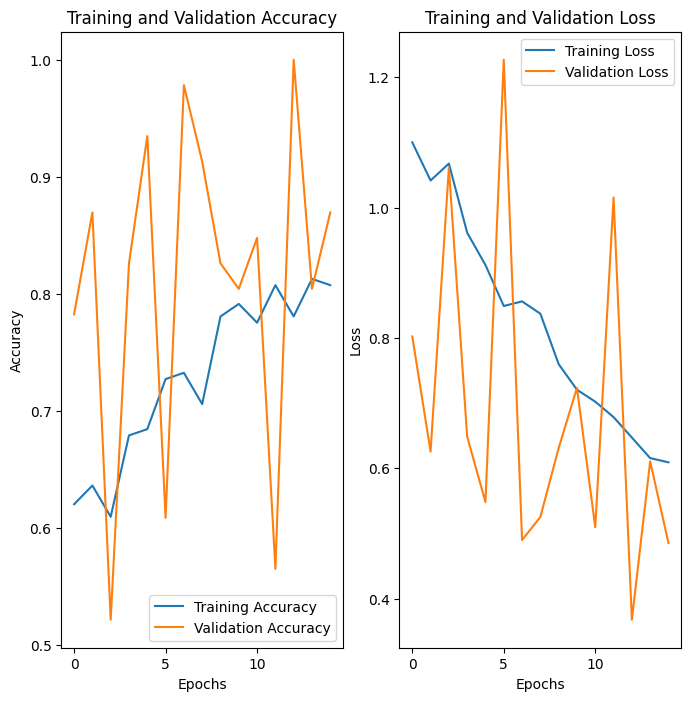

In [14]:
# plotting training and accuracy graph

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [15]:
# Use the trained ResNet-18 model to generate raw predictions for the validation set.

probabilities = model.predict(val_dataset)
print('Size of variable probabilities: ' + str(probabilities.shape)) 
# This will show (Total_Images, 6)
print('Probabilities for the first image:')
print(probabilities[0])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 
Size of variable probabilities: (46, 6)
Probabilities for the first image:
[0.11504947 0.10241227 0.19541448 0.03551931 0.22425893 0.32734555]


In [16]:
# Convert raw confidence scores (probabilities) into final category predictions.
predictions = np.argmax(probabilities, axis=1)
true_labels = np.concatenate([y for x, y in val_dataset], axis=0)
print('Size of variable predictions: ' + str(predictions.shape)) 
print('Predictions (First 10):')
print(predictions[:10]) 

print('Labels (First 10):')
print(true_labels[:10])

Size of variable predictions: (46,)
Predictions (First 10):
[5 5 2 5 5 5 5 5 5 5]
Labels (First 10):
[5 5 5 5 5 5 5 5 5 5]


2026-04-24 12:58:30.548933: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [17]:
# Convert raw confidence scores (probabilities) into final class prediction
predictions = np.argmax(probabilities, axis=1)
print('Size of variable predictions: ' + str(predictions.shape))

Size of variable predictions: (46,)


In [21]:
# Convert the model's raw probability distributions into specific class predictions. 
predictions = np.argmax(probabilities, axis=1)

true_labels = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)

2026-04-24 13:03:21.037717: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


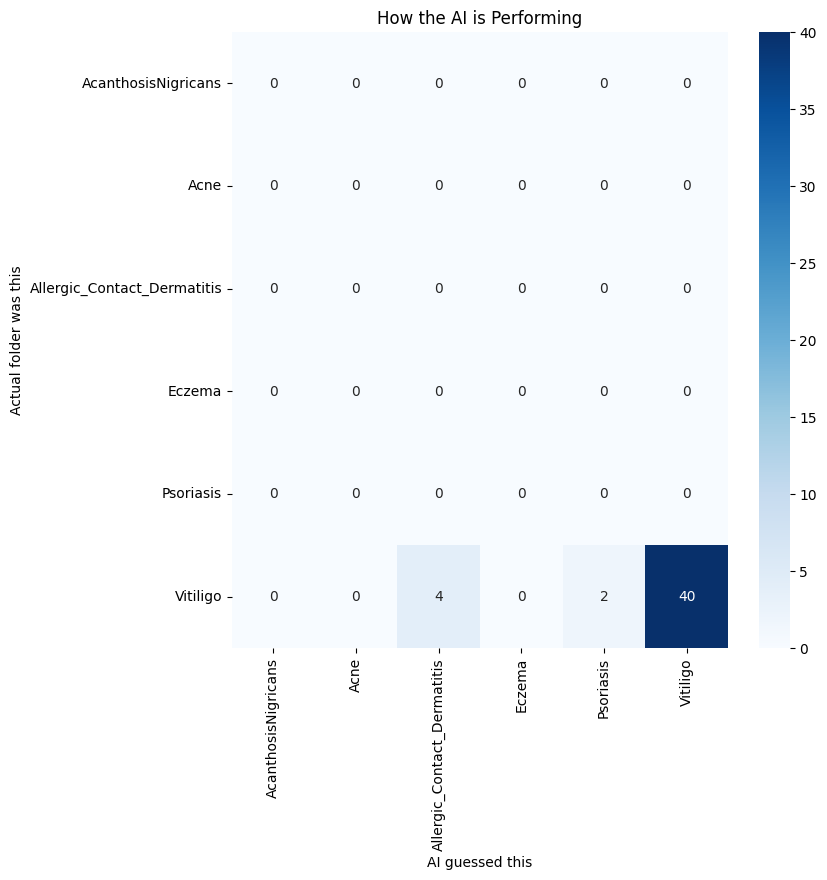

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_simple_matrix(actual, predicted, labels):

    cm = tf.math.confusion_matrix(actual, predicted)

    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)

    plt.title('How the AI is Performing')
    plt.xlabel('AI guessed this')
    plt.ylabel('Actual folder was this')
    plt.show()

# 2. RUN IT using the labels and predictions we just gathered
plot_simple_matrix(true_labels, predictions, val_dataset.class_names)

In [24]:
import numpy as np

train_labels = np.concatenate([y.numpy() for x, y in train_dataset])

2026-04-25 11:44:56.502862: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [25]:
# calculating weights to handle class imbalance into training data
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight = dict(enumerate(weights))

print(class_weight)

{0: 1.1130952380952381, 1: 1.1130952380952381, 2: 1.0053763440860215, 3: 1.1987179487179487, 4: 0.9166666666666666, 5: 0.7791666666666667}


In [26]:
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weight
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7968 - loss: 0.6212 - val_accuracy: 0.7391 - val_loss: 0.6067
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8396 - loss: 0.5694 - val_accuracy: 0.7826 - val_loss: 0.5701
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8877 - loss: 0.5175 - val_accuracy: 0.8478 - val_loss: 0.4562
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8824 - loss: 0.4988 - val_accuracy: 0.7391 - val_loss: 0.7220
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8877 - loss: 0.4648 - val_accuracy: 0.8696 - val_loss: 0.4732
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9091 - loss: 0.4436 - val_accuracy: 0.8478 - val_loss: 0.4563
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9144 - loss: 0.4250 - val_accuracy: 0.8261 - val_loss: 0.6227
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9198 - loss: 0.4079 - val_accuracy: 0.8696 - val_loss: 0.4440


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_simple_matrix(actual, predicted, labels):
    cm = tf.math.confusion_matrix(actual, predicted)

    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [30]:
import numpy as np

probabilities = model.predict(val_dataset)
predictions = np.argmax(probabilities, axis=1)

true_labels = np.concatenate([y.numpy() for x, y in val_dataset], axis=0)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 


2026-04-25 11:48:05.125812: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


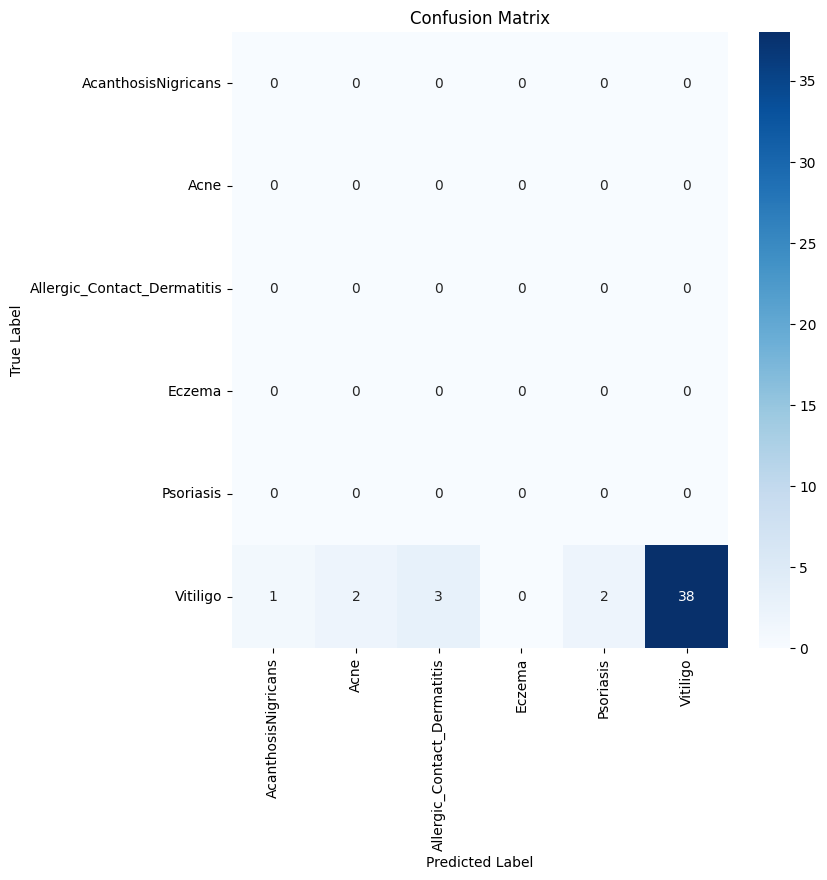

In [31]:
# plotting confusion matrix again
plot_simple_matrix(true_labels, predictions, val_dataset.class_names)